In [ ]:
import yfinance as yf
import pandas as pd

TICKER = 'AAPL'
print(f"Pulling data for {TICKER} from Yahoo Finance...")

stock = yf.Ticker(TICKER)
df_prices = stock.history(period="5y").reset_index()
df_prices['Date'] = pd.to_datetime(df_prices['Date']).dt.tz_localize(None).dt.normalize()
df_earnings = stock.get_earnings_dates()

Pulling data for AAPL from Yahoo Finance...

✅ Extraction Complete!
Loaded 1255 days of historical stock prices.

Here are the 4 most recent earnings dates:
  Earnings Date  Reported EPS  Surprise(%)
0    2026-07-30           NaN          NaN
1    2026-04-30          2.01         3.46
2    2026-01-29          2.84         6.25
3    2025-10-30          1.85         4.52


In [ ]:
df_earnings_past = df_earnings.dropna(subset=['Reported EPS']).head(8).copy()
df_prices = df_prices.sort_values('Date').reset_index(drop=True)

reaction_data = []

for _, row in df_earnings_past.iterrows():
    e_date = row['Earnings Date']
    surprise = row['Surprise(%)']
    
    closest_idx = df_prices[df_prices['Date'] <= e_date].index.max()
    
    if pd.isna(closest_idx):
        continue 
        
    try:
        price_before = df_prices.loc[closest_idx - 1, 'Close']
        price_after = df_prices.loc[closest_idx + 3, 'Close']
        
        pct_change = ((price_after - price_before) / price_before) * 100
        
        reaction_data.append({
            'Earnings Date': e_date.strftime('%Y-%m-%d'),
            'EPS Surprise (%)': round(surprise * 100, 2),
            'Pre-Earnings Price ($)': round(price_before, 2),
            'Post-Earnings Price ($)': round(price_after, 2),
            'Stock Change (%)': round(pct_change, 2)
        })
    except KeyError:
        pass

df_reaction = pd.DataFrame(reaction_data)

print(df_reaction)

✅ Analysis Complete! Here is how the market reacted to Apple's last 8 earnings reports:

  Earnings Date  EPS Surprise (%)  Pre-Earnings Price ($)  \
0    2026-04-30             346.0                  269.92   
1    2026-01-29             625.0                  255.96   
2    2025-10-30             452.0                  268.94   
3    2025-07-31             948.0                  208.22   
4    2025-05-01             150.0                  211.38   
5    2025-01-30             226.0                  237.84   
6    2024-10-31             228.0                  228.39   
7    2024-08-01             430.0                  220.17   

   Post-Earnings Price ($)  Stock Change (%)  
0                   283.92              5.19  
1                   268.98              5.09  
2                   269.28              0.13  
3                   202.12             -2.93  
4                   197.47             -6.58  
5                   231.32             -2.74  
6                   221.79      

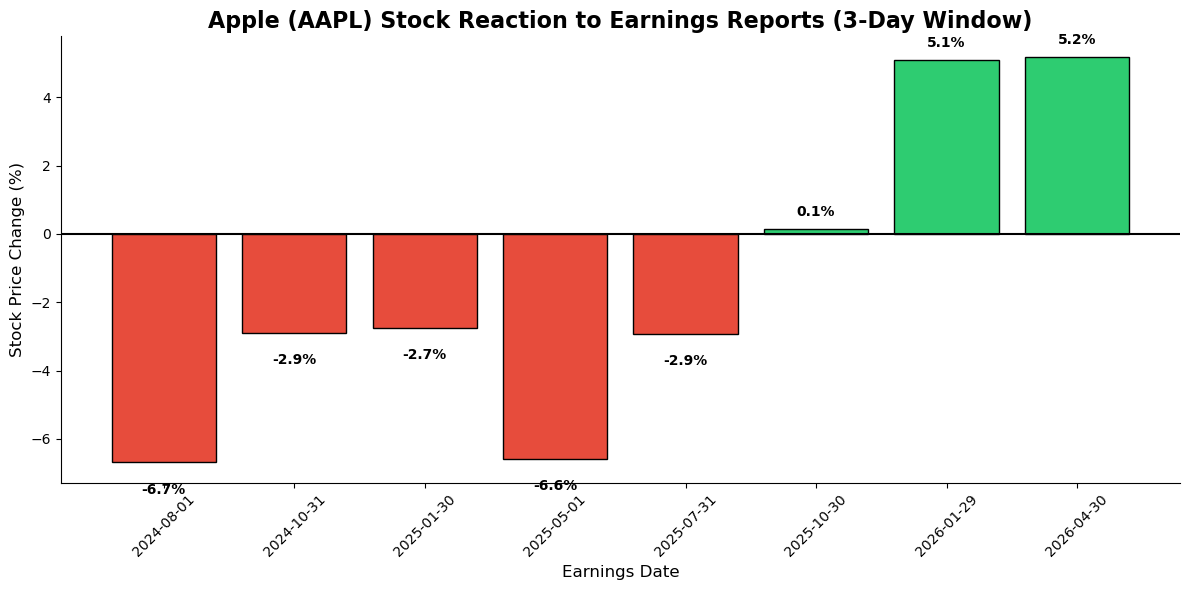

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = df_reaction.sort_values('Earnings Date').reset_index(drop=True)
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in df_plot['Stock Change (%)']]

plt.figure(figsize=(12, 6))
bars = plt.bar(df_plot['Earnings Date'], df_plot['Stock Change (%)'], color=colors, edgecolor='black')

plt.title("Apple (AAPL) Stock Reaction to Earnings Reports (3-Day Window)", fontsize=16, fontweight='bold')
plt.xlabel("Earnings Date", fontsize=12)
plt.ylabel("Stock Price Change (%)", fontsize=12)
plt.axhline(0, color='black', linewidth=1.5) 
plt.xticks(rotation=45)

for bar in bars:
    yval = bar.get_height()
    offset = 0.5 if yval > 0 else -0.8
    plt.text(bar.get_x() + bar.get_width()/2, yval + offset, 
             f"{round(yval, 1)}%", ha='center', va='center', fontweight='bold')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()